**Load Packages**

In [1]:
import pandas as pd
import numpy as np
import torch
import pymanopt
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import os
if not os.path.exists('figs'): os.makedirs('figs')
if not os.path.exists('data'): os.makedirs('data')

**Data Preprocessing**

In [2]:
# source = white wine
df_white = pd.read_csv('data/wine+quality/winequality-white.csv', sep=';') # (4898, 12)
y_s = df_white['quality'].to_numpy(dtype='float') 
x_s = df_white.drop(columns=['quality']).to_numpy()

# target = red wine
df_red = pd.read_csv('data/wine+quality/winequality-red.csv', sep=';') # (1599, 12)
y_t = df_red['quality'].to_numpy(dtype='float')   # oracle target label
x_t = df_red.drop(columns=['quality']).to_numpy()

n = len(y_s)
m = len(y_t)
d = x_s.shape[1]    # d = 11

**Regression**

We run the usual OLS regression using the source data, check its risk on the target data, and compare to the risk of the target OLS regression.

In [3]:
# transformation based on source data
x_s_avg = np.mean(x_s, axis=0)
x_s_std = np.std(x_s, axis=0)
x_t_avg = np.mean(x_t, axis=0)
x_t_std = np.std(x_t, axis=0)
x_s_scaled = (x_s - x_s_avg) / x_s_std
x_t_scaled = (x_t - x_s_avg) / x_s_std

# source risk
def R_s(beta):
    return np.mean((y_s - x_s_scaled @ beta)**2)

# target risk
def R_t(beta):
    return np.mean((y_t - x_t_scaled @ beta)**2)

# source OLS
res_s = sm.OLS(y_s, x_s_scaled).fit()
beta_s = res_s.params 
print('Source OLS risk =', R_s(beta_s))

# target OLS (oracle)
res_t = sm.OLS(y_t, x_t_scaled).fit()
beta_t = res_t.params
print('Target OLS risk (oracle) =', R_t(beta_t))
print('Target risk of source OLS =', R_t(beta_s))

Source OLS risk = 35.11297239868672
Target OLS risk (oracle) = 1.5768069471026056
Target risk of source OLS = 44.21179152393462


**Hyperparameter Selection Based on Section 5.2**

In [4]:
# pooling data
x_pool = np.vstack([x_s, x_t])

# centering
x_pool_scaled = (x_pool - np.mean(x_pool, axis=0)) / np.std(x_pool, axis=0)
pca = PCA()
pca.fit(x_pool_scaled)
print('Singular values =', pca.singular_values_)
print('Explained variance ratio (cumulative) =', np.cumsum(pca.explained_variance_ratio_))

# choose the dimension (cumulative explained variance ratio > 0.90)
k = 7

# covariance matrices
cov_s = x_s_scaled.T @ x_s_scaled / n
cov_t = x_t_scaled.T @ x_t_scaled / m
D = cov_t - cov_s
xy_s = x_s_scaled.T @ y_s / n

# to torch tensors
x_s_ = torch.from_numpy(x_s_scaled)
y_s_ = torch.from_numpy(y_s)
cov_s_ = torch.from_numpy(cov_s)
D_ = torch.from_numpy(D)
xy_s_ = torch.from_numpy(xy_s)

# optimization
manifold = pymanopt.manifolds.stiefel.Stiefel(d, k) # Stiefel manifold
@pymanopt.function.pytorch(manifold)
def cost(V):
    return torch.norm(V.T @ D_ @ V)**2

problem = pymanopt.Problem(manifold, cost)
optimizer = pymanopt.optimizers.steepest_descent.SteepestDescent(verbosity=1, max_iterations=3000)
result = optimizer.run(problem, initial_point=np.eye(d,k)) # initialization

# obtained subspace
V_stable = result.point    # numpy array

# ups (ridge parameter) scale
print('(upsilon scale) 0.1 * Source risk / squared norm ratio =', 0.1*R_s(beta_s) / np.linalg.norm(beta_s)**2)

# eta (discrepancy parameter) scale
print('(eta scale) 2 * Source risk / discrepancy ratio =', 2*R_s(beta_s) / np.linalg.norm(V_stable.T @ D @ V_stable)**2)

Singular values = [140.30344475 127.28860003 100.55638296  79.40829211  68.38879535
  62.81484049  58.30062165  57.08162889  46.79364511  38.46218119
  14.60485269]
Explained variance ratio (cumulative) = [0.2754426  0.50215406 0.64364015 0.73187216 0.79731533 0.85252548
 0.90008537 0.94567722 0.97631577 0.99701538 1.        ]
Optimizing...
Terminated - min step_size reached after 2209 iterations, 0.33 seconds.

(upsilon scale) 0.1 * Source risk / squared norm ratio = 7.196667434430779
(eta scale) 2 * Source risk / discrepancy ratio = 971.08890356613


**Proposed Method**

Implement the proposed method (Algorithm 1).

In [5]:
# initialization = identity or stable subspace
V_init = np.eye(d,k)
#V_init = V_stable

# parameters
eta_range = np.array([0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 100, 1000, 1e4, 1e5, 1e6])
ups_range = np.array([0, 0.05, 1, 7, 50])

# store results
Vs = np.zeros((len(ups_range), len(eta_range), d, k))
betas = np.zeros((len(ups_range), len(eta_range), d))
target_risks = np.zeros((len(ups_range), len(eta_range)))  # oracle target risk
source_risks = np.zeros((len(ups_range), len(eta_range)))
costs = np.zeros((len(ups_range), len(eta_range)))
discrepancies = np.zeros((len(ups_range), len(eta_range)))
grad_norms = np.zeros((len(ups_range), len(eta_range)))

# optimization
manifold = pymanopt.manifolds.stiefel.Stiefel(d, k) # Stiefel manifold
for i_ups, ups in enumerate(ups_range):
    for i_eta, eta in enumerate(eta_range):
        print(f'ups: {ups}, eta: {eta}')
        @pymanopt.function.pytorch(manifold)
        def cost(V):
            alpha_V = torch.linalg.pinv(V.T @ cov_s_ @ V + ups*torch.eye(k)) @ V.T @ xy_s_
            beta_V = V @ alpha_V
            risk_source = torch.mean((y_s_ - x_s_@beta_V)**2) + ups*torch.norm(alpha_V)**2
            discrepancy = torch.norm(V.T @ D_ @ V)**2

            return 0.5*risk_source + 0.25*eta*discrepancy

        problem = pymanopt.Problem(manifold, cost)
        optimizer = pymanopt.optimizers.steepest_descent.SteepestDescent(verbosity=1, max_iterations=3000)
        result = optimizer.run(problem, initial_point=V_init) # initialization
        
        # obtained beta
        V = result.point    # numpy array
        alpha_ridge = np.linalg.pinv(V.T @ cov_s @ V + ups*np.eye(k)) @ V.T @ xy_s
        beta_ridge = V @ alpha_ridge

        # store results
        Vs[i_ups,i_eta,:,:] = V
        betas[i_ups,i_eta,:] = beta_ridge
        target_risks[i_ups,i_eta] = R_t(beta_ridge)
        source_risks[i_ups,i_eta] = R_s(beta_ridge)
        costs[i_ups,i_eta] = problem.cost(V)
        discrepancies[i_ups,i_eta] = np.linalg.norm(V.T @ D @ V)**2
        grad_norms[i_ups,i_eta] = np.linalg.norm(problem.riemannian_gradient(V))

ups: 0.0, eta: 1e-05
Optimizing...
Terminated - max iterations reached after 1.30 seconds.

ups: 0.0, eta: 0.0001
Optimizing...
Terminated - max iterations reached after 1.32 seconds.

ups: 0.0, eta: 0.001
Optimizing...
Terminated - max iterations reached after 1.26 seconds.

ups: 0.0, eta: 0.01
Optimizing...
Terminated - min step_size reached after 1670 iterations, 0.71 seconds.

ups: 0.0, eta: 0.1
Optimizing...
Terminated - min grad norm reached after 2599 iterations, 1.06 seconds.

ups: 0.0, eta: 1.0
Optimizing...
Terminated - max iterations reached after 1.28 seconds.

ups: 0.0, eta: 100.0
Optimizing...
Terminated - max iterations reached after 1.36 seconds.

ups: 0.0, eta: 1000.0
Optimizing...
Terminated - max iterations reached after 1.33 seconds.

ups: 0.0, eta: 10000.0
Optimizing...
Terminated - max iterations reached after 1.29 seconds.

ups: 0.0, eta: 100000.0
Optimizing...
Terminated - min step_size reached after 2107 iterations, 0.90 seconds.

ups: 0.0, eta: 1000000.0
Optim

**Plots**

Reproduce the plots in Figure 6 of the paper.

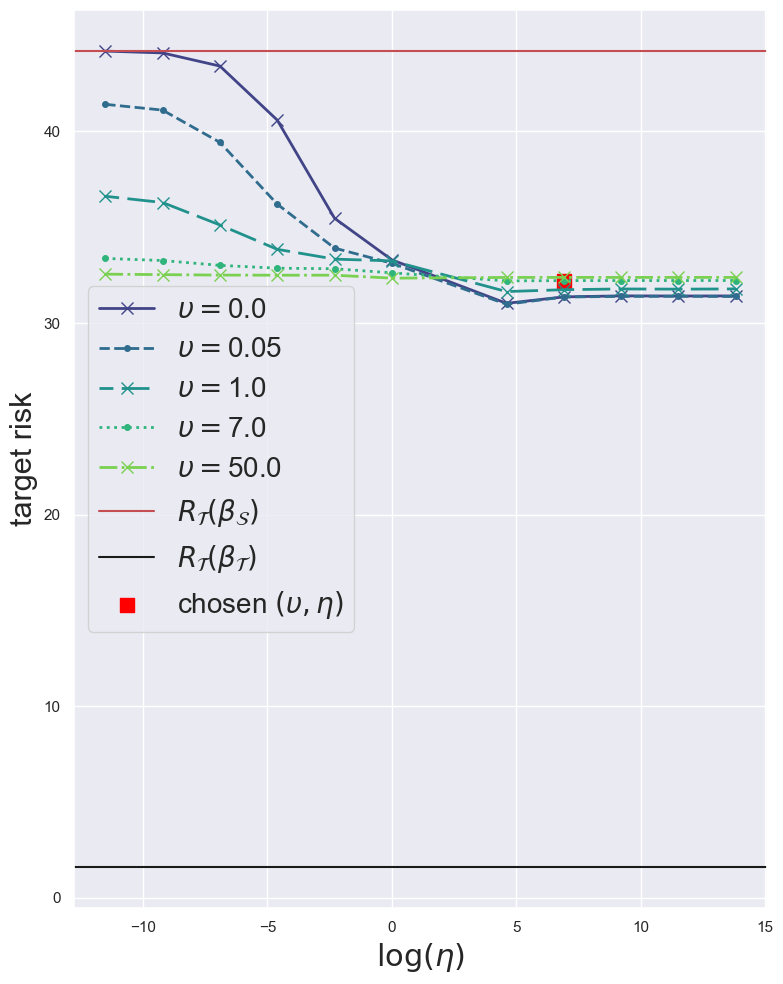

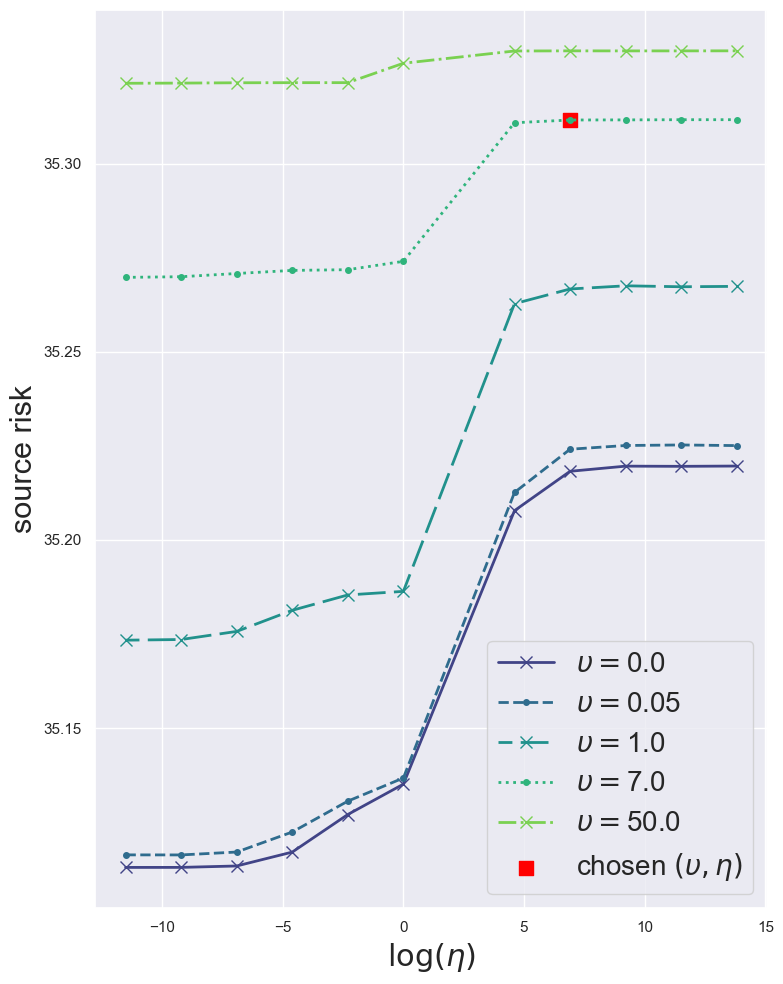

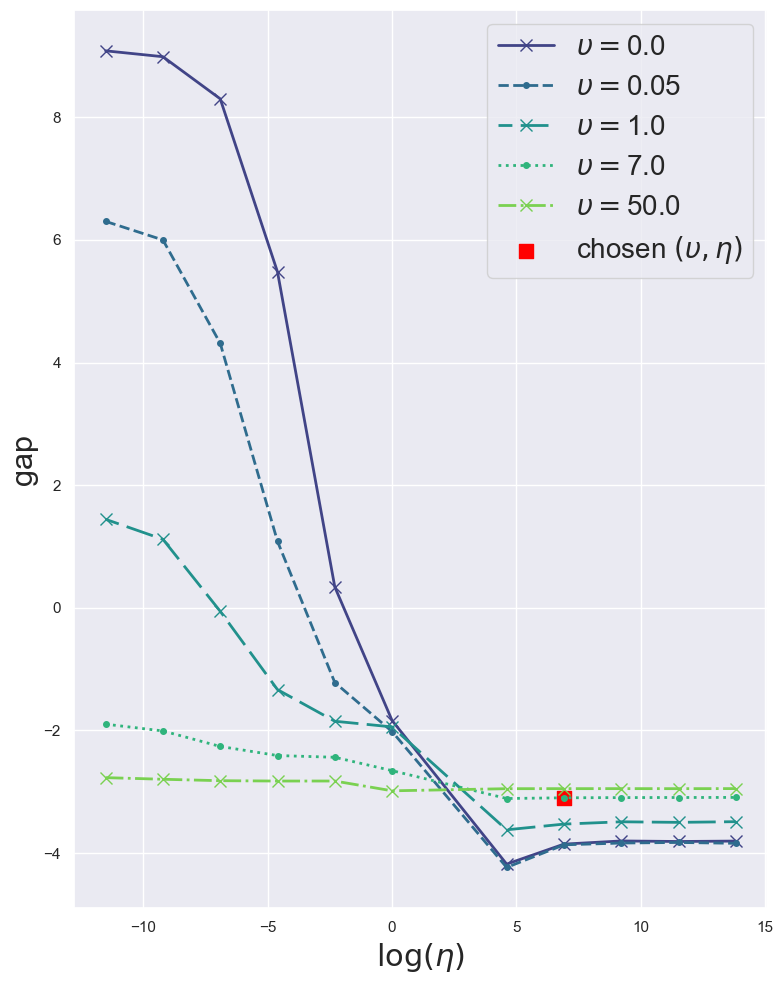

In [6]:
sns.set_theme()

linestyle_tuple = [
     ('loosely dotted',        (0, (1, 10))),
     ('dotted',                (0, (1, 1))),
     ('densely dotted',        (0, (1, 1))),
     ('long dash with offset', (5, (10, 3))),
     ('loosely dashed',        (0, (5, 10))),
     ('dashed',                (0, (5, 5))),
     ('densely dashed',        (0, (5, 1))),

     ('loosely dashdotted',    (0, (3, 10, 1, 10))),
     ('dashdotted',            (0, (3, 5, 1, 5))),
     ('densely dashdotted',    (0, (3, 1, 1, 1))),

     ('dashdotdotted',         (0, (3, 5, 1, 5, 1, 5))),
     ('loosely dashdotdotted', (0, (3, 10, 1, 10, 1, 10))),
     ('densely dashdotdotted', (0, (3, 1, 1, 1, 1, 1)))]


linestyle_list = ['solid', 'dashed', (5, (10, 3)), 'dotted', 'dashdot']
marker_list = ['x', '.', 'x', '.', 'x']
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(ups_range)))

eta_id_chosen = 7
ups_id_chosen = 3
gap = target_risks - source_risks

# target risk
fig = plt.figure(figsize=(8, 10))
for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), target_risks[j,:], markersize=8, marker=marker_list[j], color=colors[j], linestyle=linestyle_list[j], linewidth=2, label=r'$\upsilon=$'+str(ups_range[j]))

plt.axhline(R_t(beta_s), color='r', label=r'$R_\mathcal{T}(\beta_{\mathcal{S}})$')
plt.axhline(R_t(beta_t), color='k', label=r'$R_\mathcal{T}(\beta_{\mathcal{T}})$')
plt.scatter(np.log(eta_range[eta_id_chosen]), target_risks[ups_id_chosen,eta_id_chosen], color='red', s=100, marker='s', label=r'chosen $(\upsilon,\eta)$') # chosen hyperparameters
plt.ylabel('target risk', fontsize=22)
plt.xlabel(r'$\log(\eta)$', fontsize=22)
plt.legend(prop={'size': 20})
fig.tight_layout()
plt.savefig('figs/wine_target_risk.pdf')
plt.show()

# source risk
fig = plt.figure(figsize=(8, 10))
for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), source_risks[j,:], markersize=8, marker=marker_list[j], color=colors[j], linestyle=linestyle_list[j], linewidth=2, label=r'$\upsilon=$'+str(ups_range[j]))

plt.scatter(np.log(eta_range[eta_id_chosen]), source_risks[ups_id_chosen,eta_id_chosen], color='red', s=100, marker='s', label=r'chosen $(\upsilon,\eta)$') # chosen hyperparameters
plt.ylabel('source risk', fontsize=22)
plt.xlabel(r'$\log(\eta)$', fontsize=22)
plt.legend(prop={'size': 20})
fig.tight_layout()
plt.savefig('figs/wine_source_risk.pdf')
plt.show()

# target risk - source risk
fig = plt.figure(figsize=(8, 10))
for j in range(len(ups_range)):
    plt.plot(np.log(eta_range), gap[j,:], markersize=8, marker=marker_list[j], color=colors[j], linestyle=linestyle_list[j], linewidth=2, label=r'$\upsilon=$'+str(ups_range[j]))

plt.scatter(np.log(eta_range[eta_id_chosen]), gap[ups_id_chosen,eta_id_chosen], color='red', s=100, marker='s', label=r'chosen $(\upsilon,\eta)$') # chosen hyperparameters
plt.ylabel('gap', fontsize=22)
plt.xlabel(r'$\log(\eta)$', fontsize=22)
plt.legend(prop={'size': 20})
fig.tight_layout()
plt.savefig('figs/wine_target_source_difference.pdf')
plt.show()